In [32]:
import os
import numpy as np
import rasterio as rio
from rasterio.merge import merge
from rasterio.plot import show
from datetime import datetime, timedelta
from pathlib import Path

In [44]:
# Example usage
folder_path = "/home/sirsimsius/Hentet"  # Replace with your folder path
output_folder = "monthly_cloud"  # Replace with your desired output folder

In [35]:
naming_con = "GEMLST_MODIS_YYYYMMDD.tif" 

files = sorted(Path(folder_path).glob("*.tif"))

dates = [f.stem.split("_")[2] for f in files]

unique_months = sorted(set(date[:6] for date in dates))

print(files)

[PosixPath('/home/sirsimsius/Hentet/GEMLST_MODIS_20190112.tif'), PosixPath('/home/sirsimsius/Hentet/GEMLST_MODIS_20190113.tif'), PosixPath('/home/sirsimsius/Hentet/GEMLST_MODIS_20190114.tif'), PosixPath('/home/sirsimsius/Hentet/GEMLST_MODIS_20201219.tif'), PosixPath('/home/sirsimsius/Hentet/GEMLST_MODIS_20210107.tif')]


In [58]:
def reclassify(img):
    # Count pixels with value 0; all other values contribute 0.
    return np.where(img == 0, 1, 0).astype(np.uint8)

def process_monthly_averages(folder_path):

    for month in sorted(unique_months):    
        monthly_files = [f for f in files if f.stem.startswith(f"GEMLST_MODIS_{month}")]
        with rio.open(monthly_files[0]) as img:
            first_img = img.read(2)
            count_img = reclassify(first_img)
            profile = img.profile
        
        # Open and read all files for the month
        for file in monthly_files[1:]:
            with rio.open(file) as src:
                data = src.read(2)
                data = reclassify(data)
                count_img += data

        # Save the monthly average as a GeoTIFF
        output_filename = f"MONTHLY_AVG_{month}.tiff"
        output_path = os.path.join(folder_path, output_filename)

        with rio.open(
            output_path,
            'w',
            driver='GTiff',
            height=count_img.shape[0],
            width=count_img.shape[1],
            count=1,
            dtype='uint8',
            crs=profile['crs'],
            transform=profile['transform']
        ) as dst:
            dst.write(count_img, 1)

        print(f"Saved: {output_path}")

process_monthly_averages(folder_path)

Saved: /home/sirsimsius/Hentet/MONTHLY_AVG_201901.tiff
Saved: /home/sirsimsius/Hentet/MONTHLY_AVG_202012.tiff
Saved: /home/sirsimsius/Hentet/MONTHLY_AVG_202101.tiff


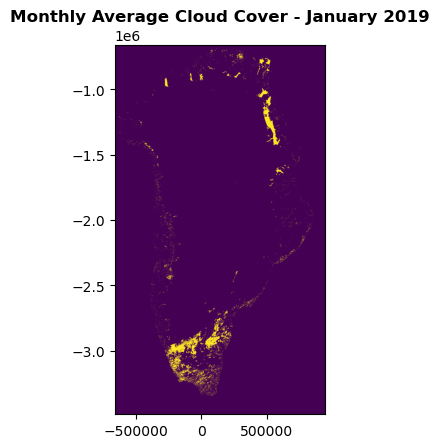

In [51]:
with rio.open("/home/sirsimsius/Hentet/MONTHLY_AVG_201901.tiff") as src:
    show(src, title="Test")

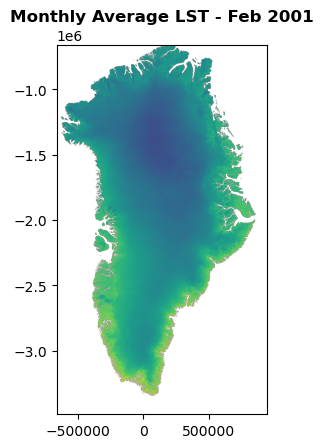

In [54]:
with rio.open("/home/sirsimsius/Hentet/GEMLST_monthly_2001_02.tiff") as src:
    show(src, title="Monthly Average LST - Feb 2001")


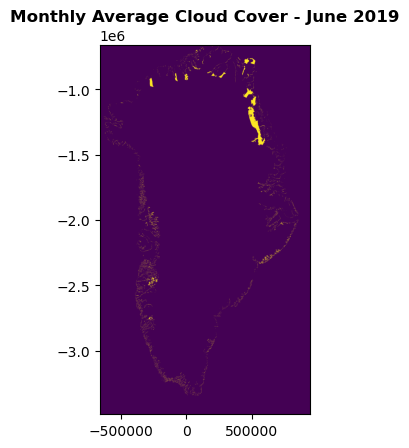

In [56]:
with rio.open("/home/sirsimsius/Hentet/MONTHLY_CLOUD_200006.tiff") as src:
    show(src, title="Monthly Average Cloud Cover - June 2019")


In [7]:
import numpy as np
from numpy.random import randint
jan = randint(-30, 30, 31)
feb = randint(-30, 30, 28)
mar = randint(-30, 30, 31)

avg_jan = jan.mean()
avg_feb = feb.mean()
avg_mar = mar.mean()
agg_avg = (avg_jan + avg_feb + avg_mar) / 3

all = np.concatenate([jan, feb, mar])
print(all.mean())
print(agg_avg)


-3.4
-3.4112903225806455
